<a href="https://colab.research.google.com/github/ximeniki/Household-Power-Forecasting/blob/main/VARGAS_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display

df = pd.read_csv('/content/drive/MyDrive/household_power_consumption.txt',sep = ";")

/tmp/ipython-input-823542170.py:8: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/household_power_consumption.txt',sep = ";")


In [ ]:
display(df.head())
print(df.shape)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


(2075259, 9)


In [ ]:
display(df.isnull().sum())

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,25979


In [ ]:
df['Sub_metering_3'] = df['Sub_metering_3'].ffill()
display(df.isnull().sum())

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0


In [ ]:
df_tsa = df.copy()

df_tsa['Time stamp'] = df_tsa['Date'] + ' ' + df_tsa['Time'] #combine date and time, make them time index
df_tsa['Time stamp'] = pd.to_datetime(df_tsa['Time stamp'], format='%d/%m/%Y %H:%M:%S')
df_tsa.set_index('Time stamp', inplace=True)

df_tsa.drop(['Date', 'Time'], axis=1, inplace=True)
df_tsa = df_tsa.apply(pd.to_numeric, errors='coerce')
df_tsa = df_tsa.ffill()

df_hourly = df_tsa.resample('h').mean()#Resampling hourly mean
print("\nHourly resampled")
display(df_hourly.head())



Hourly resampled


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Time stamp,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


# FEATURE ENGINEERING

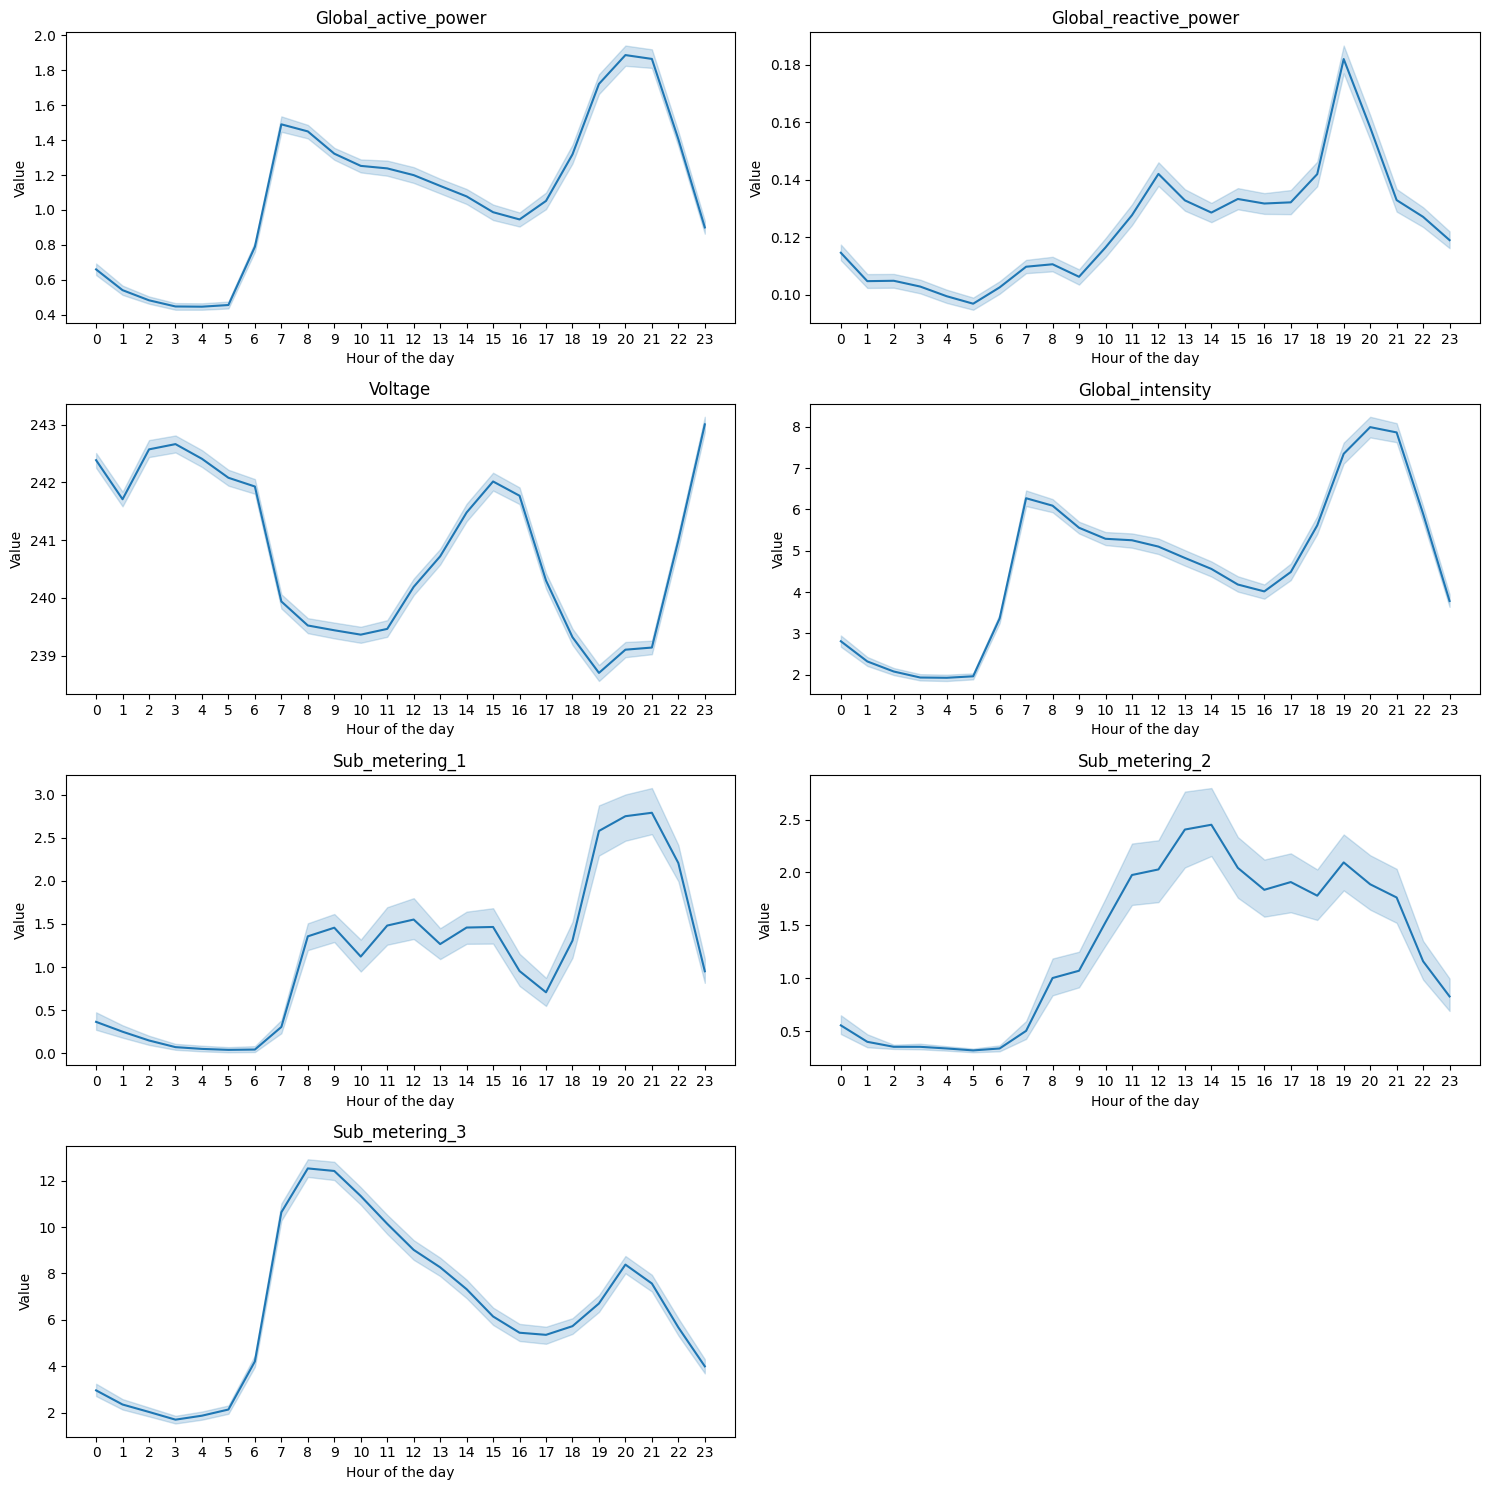

In [ ]:
hours = df_hourly.index.hour

cols = df_hourly.columns
plt.figure(figsize=(15,15))

for i, col in enumerate(cols, 1):
    plt.subplot(4, 2, i)
    sns.lineplot(x=hours, y=df_hourly[col])
    plt.title(col)
    plt.xlabel("Hour of the day")
    plt.ylabel("Value")
    plt.xticks(range(24))

plt.tight_layout()
plt.show()


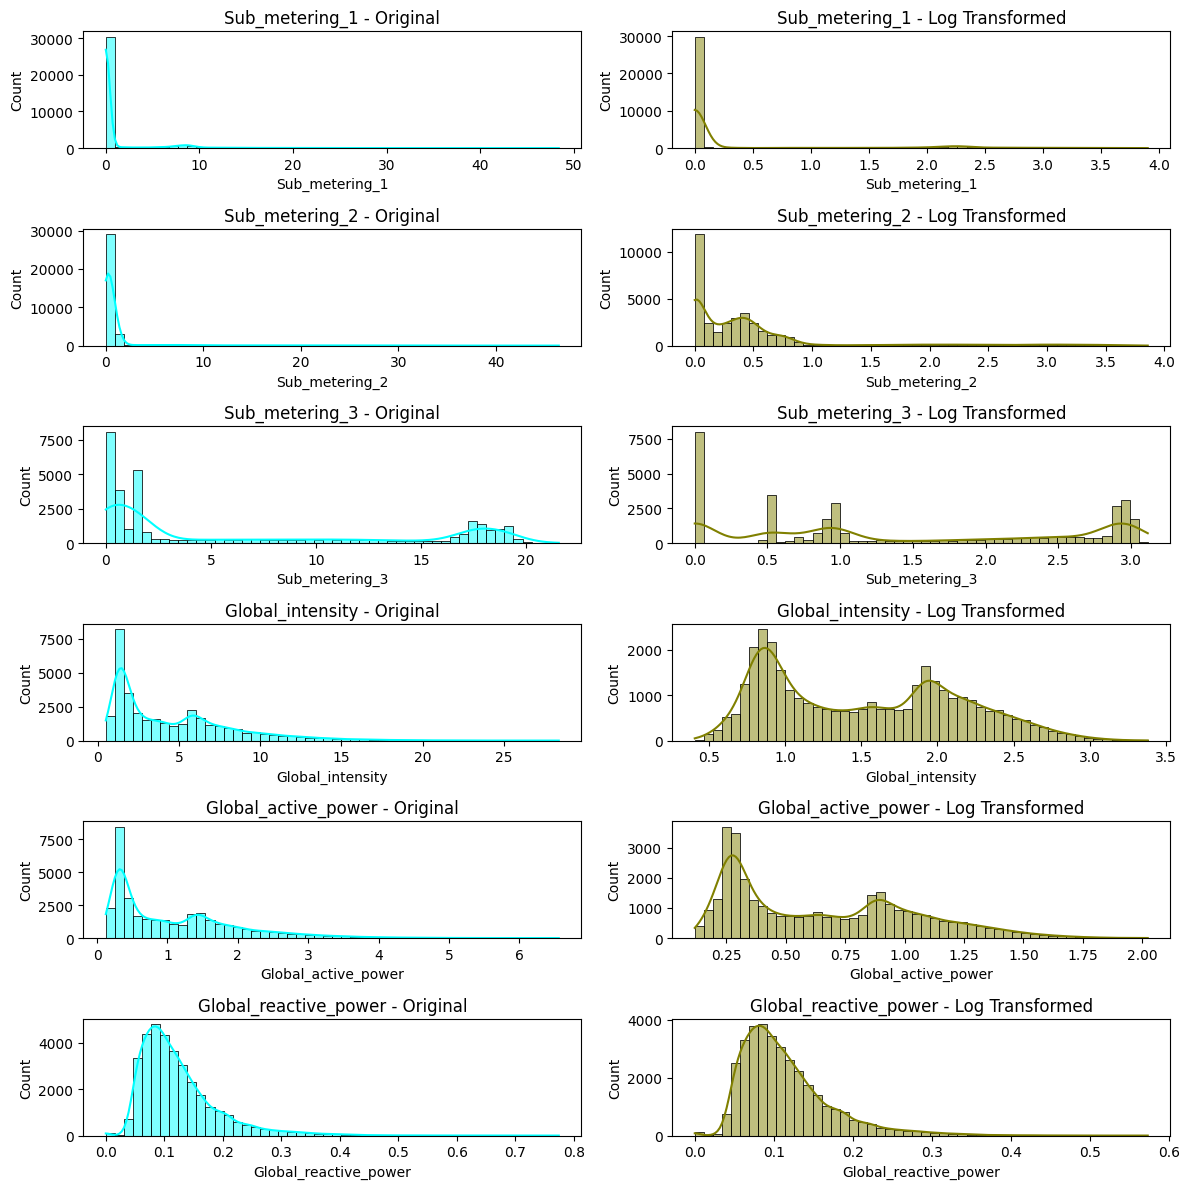

In [ ]:
cols_trans = ["Sub_metering_1", "Sub_metering_2", "Sub_metering_3",
                     "Global_intensity", "Global_active_power", "Global_reactive_power"]
df_hourly_log = df_hourly[cols_trans].copy() #Applying log transforms to features that are skewed to the right

for col in cols_trans:
    df_hourly_log[col] = np.log1p(df_hourly_log[col])

df_hourly_log["Voltage"] = df_hourly["Voltage"]#adding voltage without log transform

fig, axes = plt.subplots(6, 2, figsize=(12, 12))

for i, col in enumerate(cols_trans):
    sns.histplot(df_hourly[col], bins=50, kde=True, ax=axes[i, 0], color='cyan')
    axes[i, 0].set_title(f"{col} - Original")

    sns.histplot(df_hourly_log[col], bins=50, kde=True, ax=axes[i, 1], color='olive')
    axes[i, 1].set_title(f"{col} - Log Transformed")


plt.tight_layout()
plt.show()

                     Sub_metering_1  Sub_metering_2  Sub_metering_3  \
Time stamp                                                            
2006-12-16 17:00:00       -0.368152       -0.001817        1.293224   
2006-12-16 18:00:00       -0.368152        2.521292        1.293495   
2006-12-16 19:00:00       -0.368152        0.723299        1.284514   
2006-12-16 20:00:00       -0.368152       -0.662073        1.289424   
2006-12-16 21:00:00       -0.368152       -0.119450        1.310386   

                     Global_intensity  Global_active_power  \
Time stamp                                                   
2006-12-16 17:00:00          2.276673             2.579886   
2006-12-16 18:00:00          2.052883             2.269309   
2006-12-16 19:00:00          1.943851             2.136366   
2006-12-16 20:00:00          1.882313             2.057752   
2006-12-16 21:00:00          1.786448             1.925866   

                     Global_reactive_power   Voltage  
Time stamp  

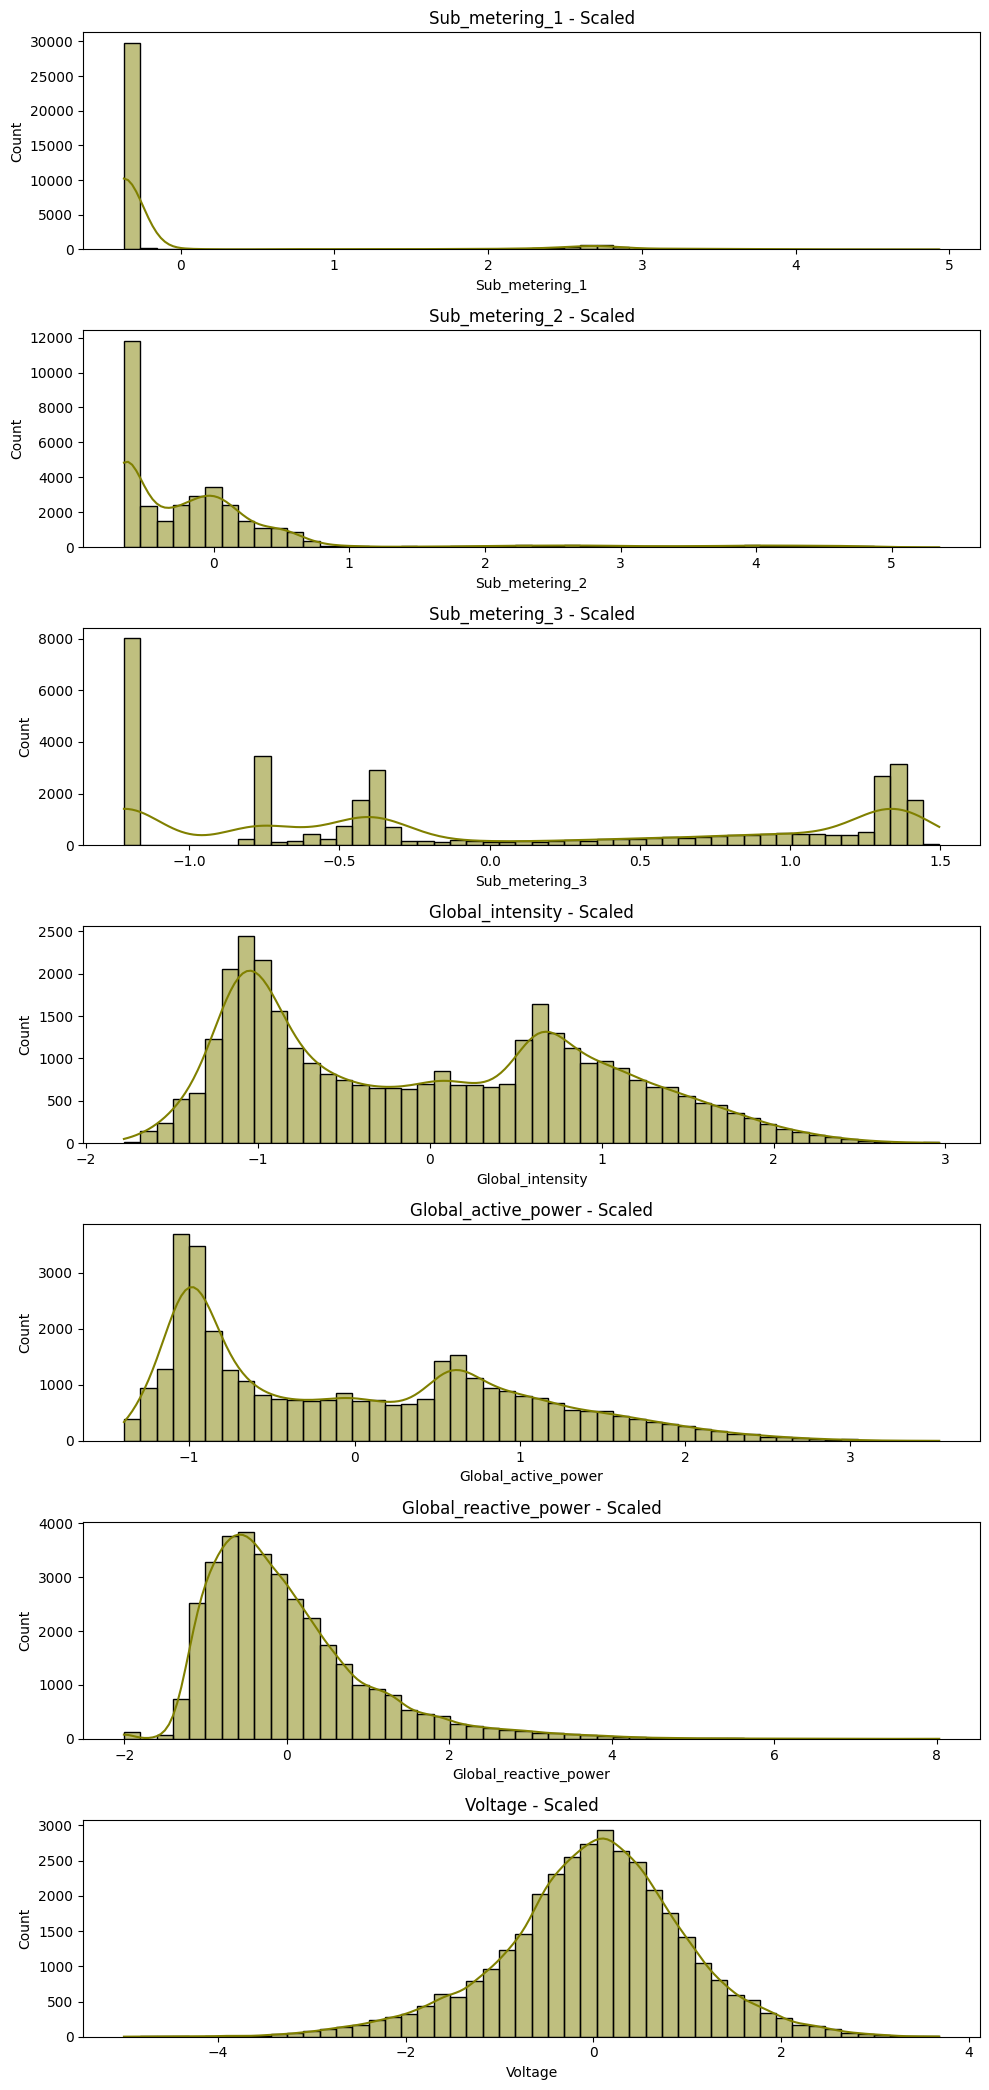

In [ ]:
from sklearn.preprocessing import StandardScaler

df_hourly_scaled = df_hourly_log.copy()#scaling features

scaler = StandardScaler()
df_hourly_scaled[df_hourly_scaled.columns] = scaler.fit_transform(df_hourly_scaled)

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(len(df_hourly_scaled.columns), 1, figsize=(10, 3*len(df_hourly_scaled.columns)))

for i, col in enumerate(df_hourly_scaled.columns):
    sns.histplot(df_hourly_scaled[col], bins=50, kde=True, ax=axes[i], color='olive')
    axes[i].set_title(f"{col} - Scaled")

plt.tight_layout()
plt.show()

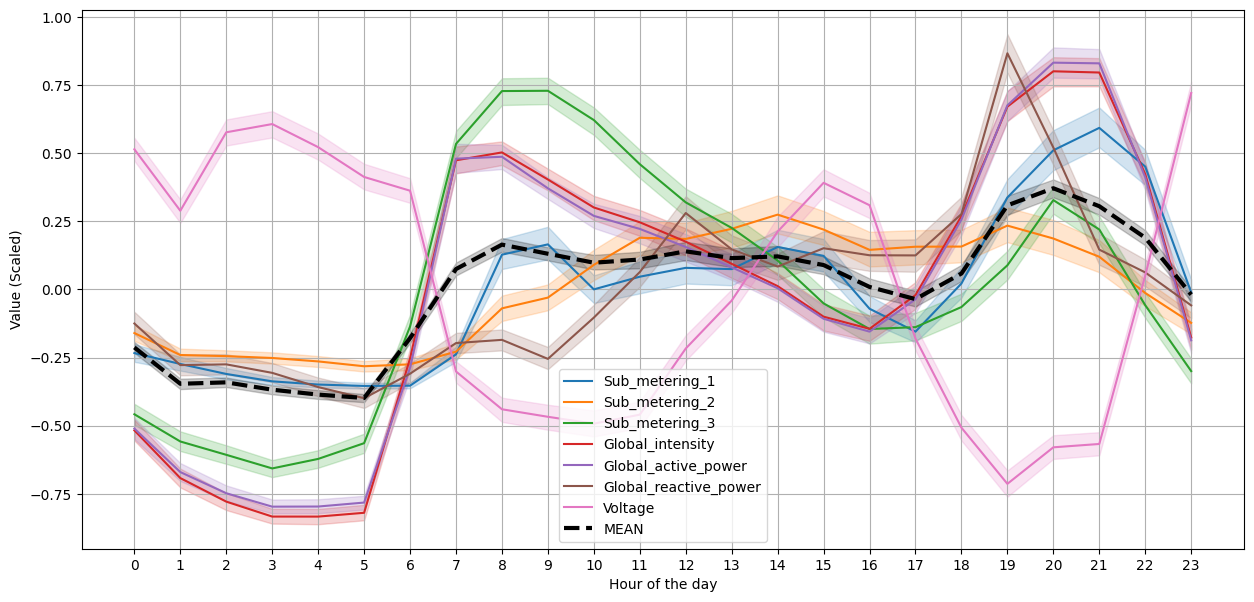

In [ ]:
cols = df_hourly_scaled.columns

plt.figure(figsize=(15, 7))
palette = sns.color_palette("tab10", n_colors=len(cols))

for i, col in enumerate(cols):
    if col != 'hour':
        sns.lineplot(x=hours, y=df_hourly_scaled[col], label=col, color=palette[i])

mean_values = df_hourly_scaled.mean(axis=1)
sns.lineplot(x=hours, y=mean_values, label='MEAN', color='black', linewidth=3, linestyle='--')

plt.xlabel("Hour of the day")
plt.ylabel("Value (Scaled)")
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
hours = df_hourly.index.hour
display(df_hourly.head())


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Time stamp,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


Index([17, 18, 19, 20, 21, 22, 23,  0,  1,  2,
       ...
       12, 13, 14, 15, 16, 17, 18, 19, 20, 21],
      dtype='int32', name='Time stamp', length=34589)

Global_active_power      1.000000
Global_intensity         0.994505
Sub_metering_3           0.725537
Sub_metering_1           0.474080
Sub_metering_2           0.371765
hour                     0.342566
Global_reactive_power    0.283723
Voltage                 -0.360871
Name: Global_active_power, dtype: float64


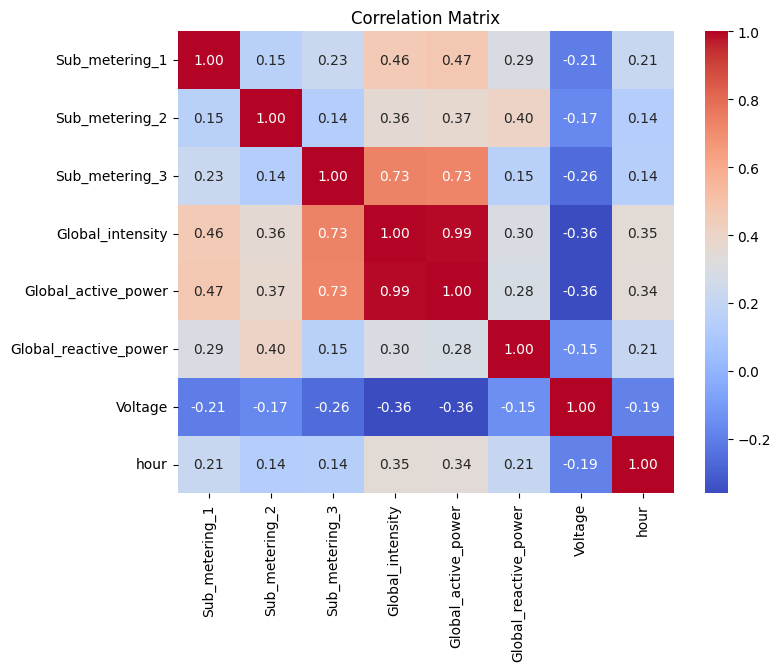

In [ ]:
corr = df_hourly_scaled.corr()["Global_active_power"].sort_values(ascending=False)

print(corr)

plt.figure(figsize=(8,6))
sns.heatmap(df_hourly_scaled.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

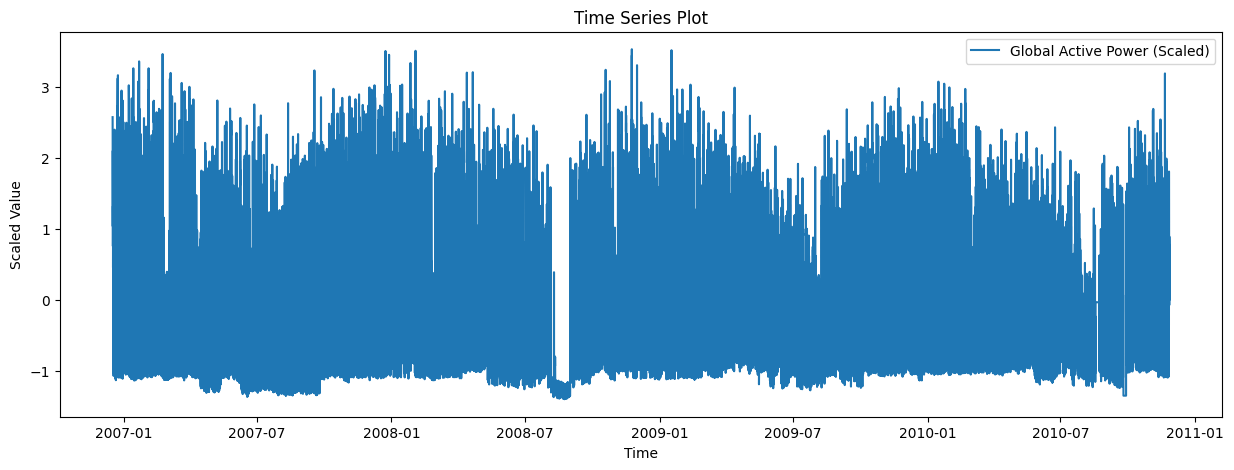

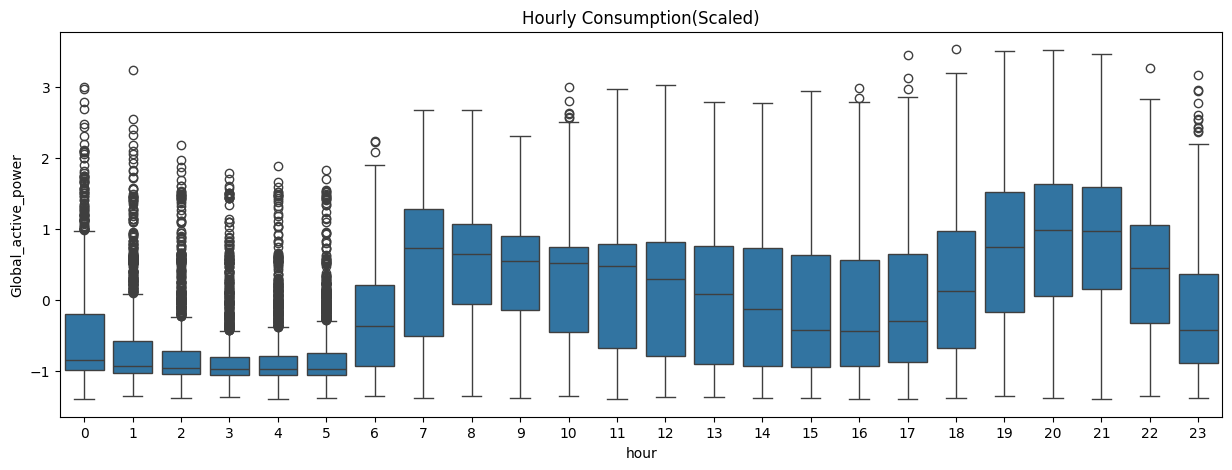

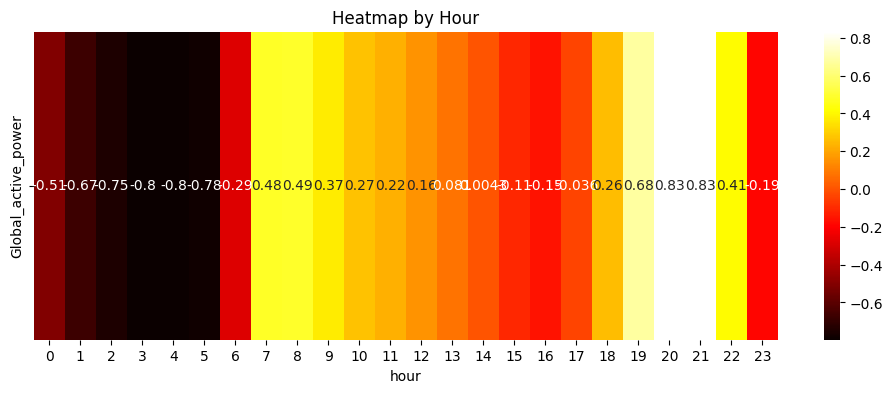

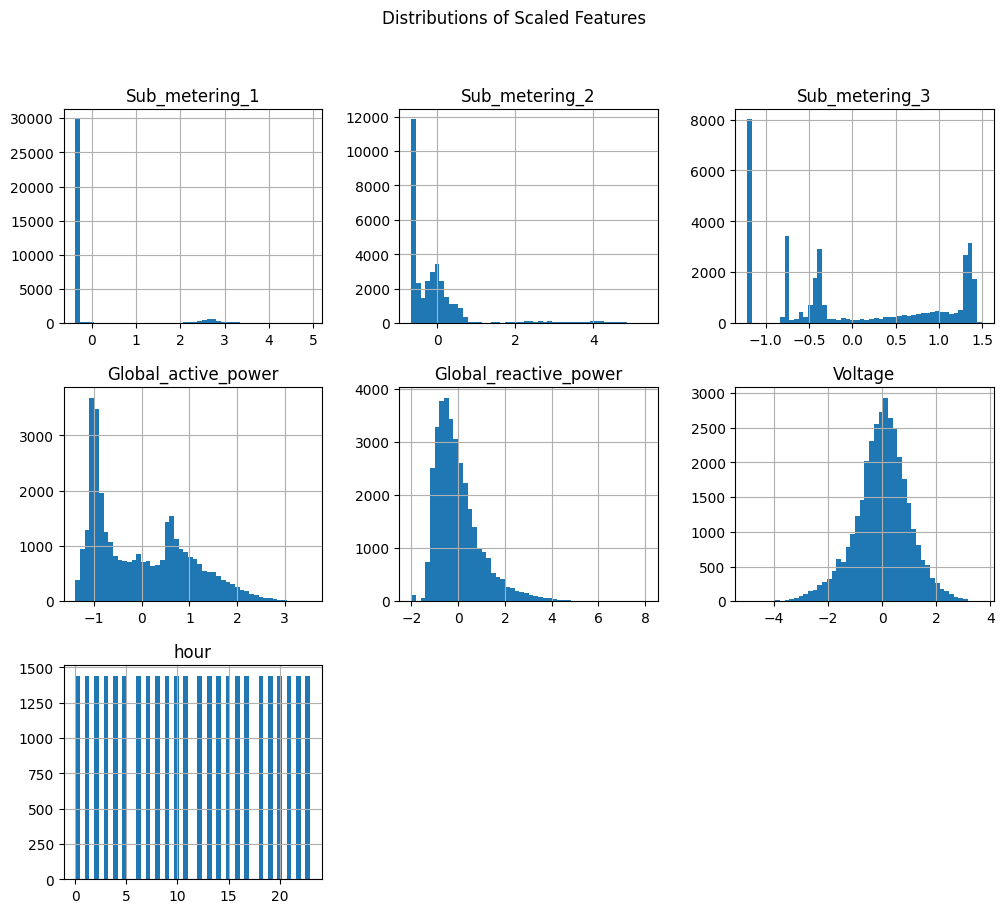

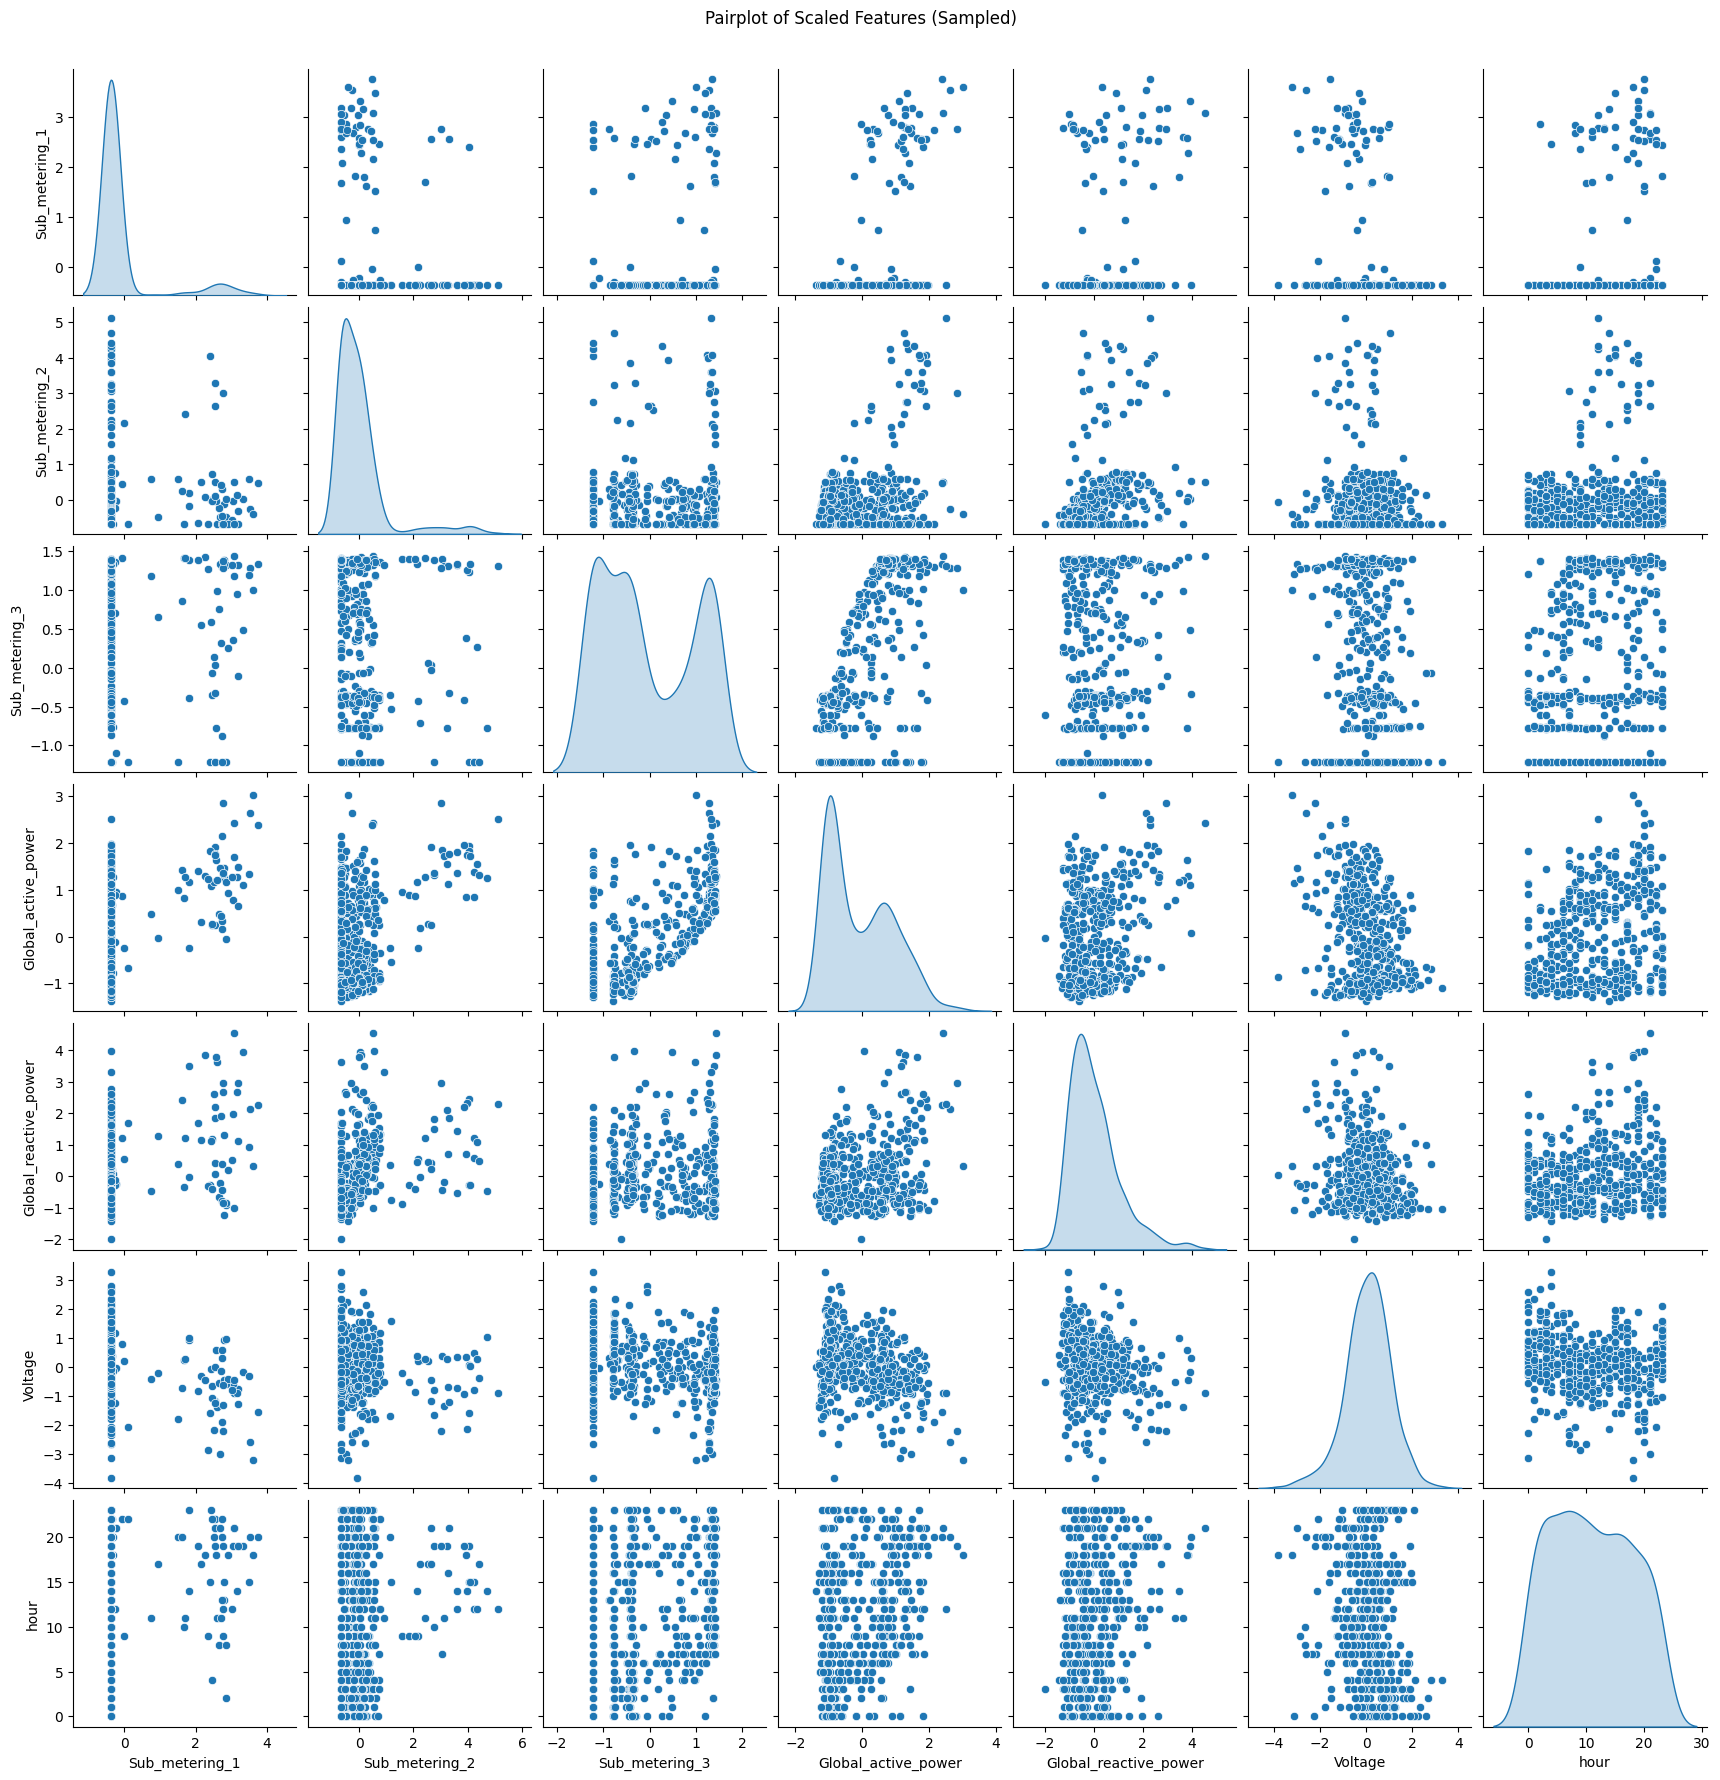

In [ ]:
from statsmodels.tsa.stattools import adfuller

df_hourly_scaled = df_hourly_scaled.drop(columns=['Global_intensity'], errors='ignore')#Deleting global intensinty feature

#Time Series
plt.figure(figsize=(15,5))
plt.plot(df_hourly_scaled.index, df_hourly_scaled['Global_active_power'], label='Global Active Power (Scaled)')
plt.title("Time Series Plot")
plt.xlabel("Time")
plt.ylabel("Scaled Value")
plt.legend()
plt.show()

#Seasonality
plt.figure(figsize=(15,5))
sns.boxplot(x='hour', y='Global_active_power', data=df_hourly_scaled)
plt.title("Hourly Consumption(Scaled)")
plt.show()

#Heatmap
pivot = df_hourly_scaled.pivot_table(index='hour', values='Global_active_power', aggfunc='mean')
plt.figure(figsize=(12,4))
sns.heatmap(pivot.T, cmap="hot", annot=True)
plt.title("Heatmap by Hour")
plt.show()

#Distribution Analysis
df_hourly_scaled.hist(figsize=(12,10), bins=50)
plt.suptitle("Distributions of Scaled Features")
plt.show()

#Feature relationships
sns.pairplot(df_hourly_scaled.sample(500), diag_kind="kde")
plt.suptitle("Pairplot of Scaled Features (Sampled)", y=1.02)
plt.show()

In [ ]:
display(df_hourly_scaled.describe().T)
print(df_hourly_scaled.info())

,count,mean,std,min,25%,50%,75%,max
Sub_metering_1,34589.0,4.889103e-17,1.000014,-0.368152,-0.368152,-0.368152,-0.368152,4.933333
Sub_metering_2,34589.0,-3.533301e-17,1.000014,-0.662073,-0.662073,-0.213896,0.118080,5.350332
Sub_metering_3,34589.0,1.314717e-16,1.000014,-1.216646,-0.780627,-0.368108,1.146047,1.496190
Global_active_power,34589.0,-1.203787e-16,1.000014,-1.395285,-0.937978,-0.177408,0.749802,3.537067
Global_reactive_power,34589.0,9.860375e-18,1.000014,-2.006249,-0.696934,-0.230529,0.430590,8.031340
Voltage,34589.0,1.434849e-14,1.000014,-5.003864,-0.548280,0.047680,0.616965,3.687959
hour,34589.0,1.150108e+01,6.922394,0.000000,6.000000,12.000000,18.000000,23.000000


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34589 entries, 2006-12-16 17:00:00 to 2010-11-26 21:00:00
Freq: h
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sub_metering_1         34589 non-null  float64
 1   Sub_metering_2         34589 non-null  float64
 2   Sub_metering_3         34589 non-null  float64
 3   Global_active_power    34589 non-null  float64
 4   Global_reactive_power  34589 non-null  float64
 5   Voltage                34589 non-null  float64
 6   hour                   34589 non-null  int32  
dtypes: float64(6), int32(1)
memory usage: 3.0 MB
None


In [ ]:
train_size = 0.8
n = len(df_hourly_scaled)
split_index = int(n * train_size)

train = df_hourly_scaled.iloc[:split_index]
test = df_hourly_scaled.iloc[split_index:]
#takes the first data as training (oldest inputs) and then takes the latests data to test (newest inputs)

print(f"Training set: {train.shape[0]} rows")
print(f"Testing set: {test.shape[0]} rows")


Training set: 27671 rows
Testing set: 6918 rows


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error

y = df_hourly_scaled['Global_active_power'] #defining target feature
X = df_hourly_scaled.drop(columns=['Global_active_power']) #dropping target feature to leave the only the rest of features

train_size = 0.8 #training
n = len(df_hourly_scaled)
split_index = int(n * train_size) #splitting data

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:] #takes the first data as training (oldest inputs) and then takes the latests data to test (newest inputs)
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]#takes the first data as training (oldest inputs) and then takes the latests data to test (newest inputs)


models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),#sets that the model to use a specific randomness
    "SVM": SVR(kernel='rbf')# creates an SVM model with a rbf kernel
}
results = {}
metrics = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results[name] = {
        "model": model,
        "y_train_pred": y_train_pred,
        "y_pred": y_test_pred
    }

    mae_train = mean_absolute_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    r2_train = r2_score(y_train, y_train_pred)

    mae_test = mean_absolute_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    r2_test = r2_score(y_test, y_test_pred)

    metrics.append({
        "Model": name,
        "MAE_Train": mae_train,
        "RMSE_Train": rmse_train,
        "R2_Train": r2_train,
        "MAE_Test": mae_test,
        "RMSE_Test": rmse_test,
        "R2_Test": r2_test
    })

    print(f"{name} - MAE: {mae_test:.4f}, RMSE: {rmse_test:.4f}, R2: {r2_test:.4f}")


Linear Regression - MAE: 0.3636, RMSE: 0.4481, R2: 0.7339
Random Forest - MAE: 0.2475, RMSE: 0.3524, R2: 0.8355
SVM - MAE: 0.2511, RMSE: 0.3551, R2: 0.8330


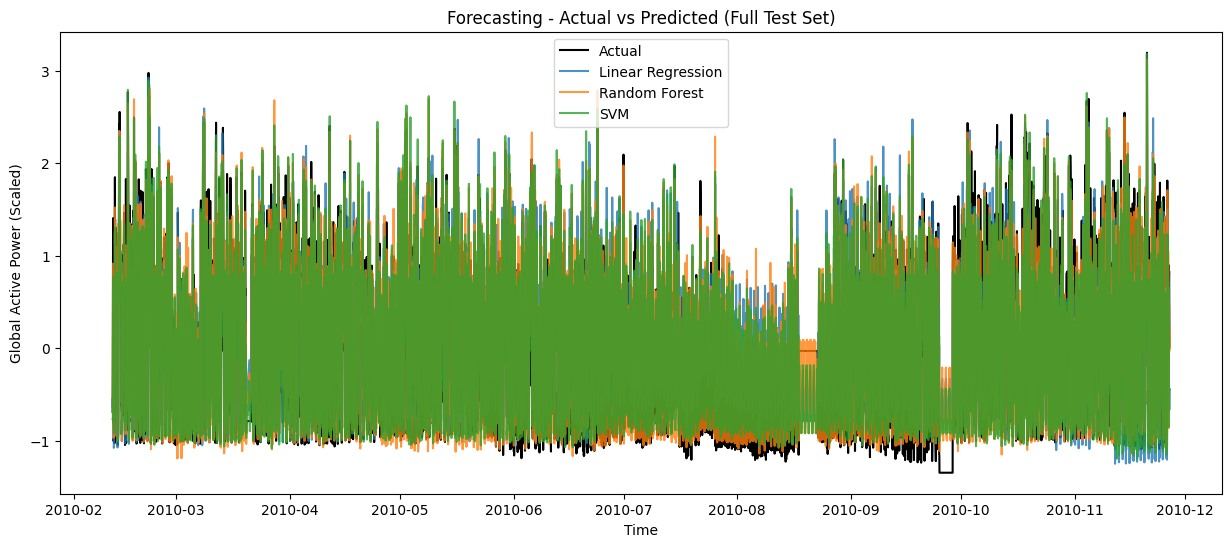

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.plot(y_test.index, y_test, label='Actual', color='black')
for name, res in results.items():
    plt.plot(y_test.index, res["y_pred"], label=name, alpha=0.8)
plt.title("Forecasting - Actual vs Predicted (Full Test Set)")
plt.xlabel("Time")
plt.ylabel("Global Active Power (Scaled)")
plt.legend()
plt.show()

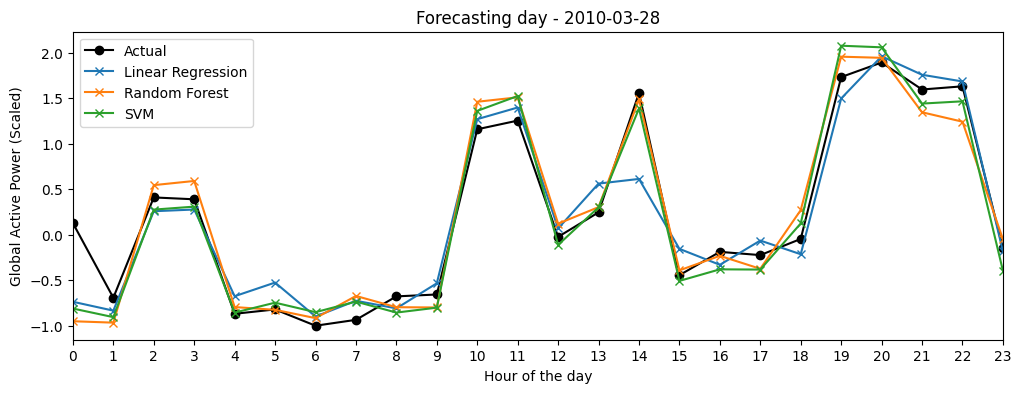

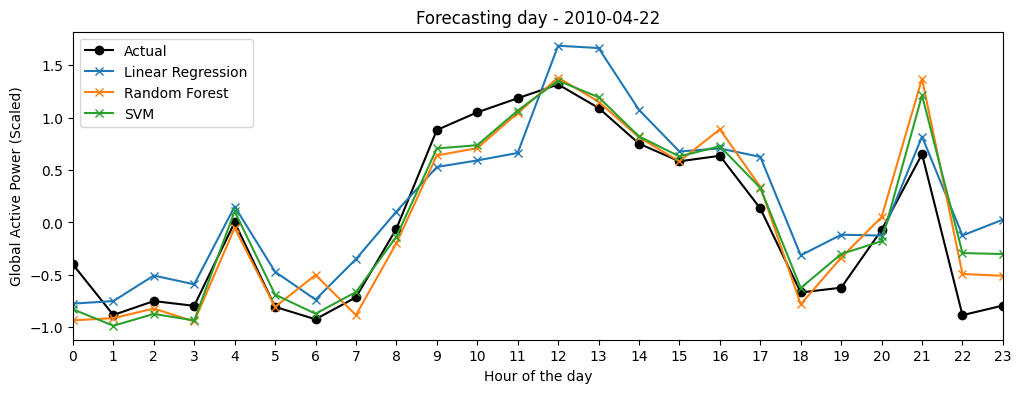

In [ ]:
import pandas as pd

test_dates = y_test.index.normalize().unique()
random_days = np.random.choice(test_dates, size=2, replace=False)#set random days

for day in random_days:
    day_mask = (y_test.index.normalize() == day)
    plt.figure(figsize=(12,4))
    plt.title(f"Forecasting day - {pd.Timestamp(day).date()}")#convert time stamp
    plt.plot(y_test.index[day_mask].hour, y_test[day_mask], label='Actual', color='black', marker='o')
    for name, res in results.items():
        plt.plot(y_test.index[day_mask].hour, res["y_pred"][day_mask], label=name, marker='x')
    plt.xlabel("Hour of the day")
    plt.ylabel("Global Active Power (Scaled)")
    plt.xlim(0,23)
    plt.xticks(range(0,24))
    plt.legend()
    plt.show()

In [ ]:
metrics_df = pd.DataFrame(metrics).set_index("Model")
display(metrics_df.style.format("{:.4f}"))

,MAE_Train,RMSE_Train,R2_Train,MAE_Test,RMSE_Test,R2_Test
Model,,,,,,
Linear Regression,0.4117,0.5527,0.7117,0.3636,0.4481,0.7339
Random Forest,0.1117,0.1662,0.9739,0.2475,0.3524,0.8355
SVM,0.3124,0.4809,0.7818,0.2511,0.3551,0.8330
